In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nopdev/real-and-fake-news-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/real-and-fake-news-dataset


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


import re

print("Tensorflow Version",tf.__version__)

Tensorflow Version 2.18.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df=pd.read_csv(path+'/news.csv')
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [ ]:
df = df.drop(['Unnamed: 0'], axis=1)

In [ ]:
df['text']=df['title']+'_______'+df['text']
df

,title,text,label
0,You Can Smell Hillary’s Fear,You Can Smell Hillary’s Fear_______Daniel Gree...,FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE
2,Kerry to go to Paris in gesture of sympathy,Kerry to go to Paris in gesture of sympathy___...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,Bernie supporters on Twitter erupt in anger ag...,FAKE
4,The Battle of New York: Why This Primary Matters,The Battle of New York: Why This Primary Matte...,REAL
...,...,...,...
6330,State Department says it can't find emails fro...,State Department says it can't find emails fro...,REAL
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligarc...,FAKE
6333,"In Ethiopia, Obama seeks progress on peace, se...","In Ethiopia, Obama seeks progress on peace, se...",REAL


In [ ]:
df=df.drop(['title'],axis=1)

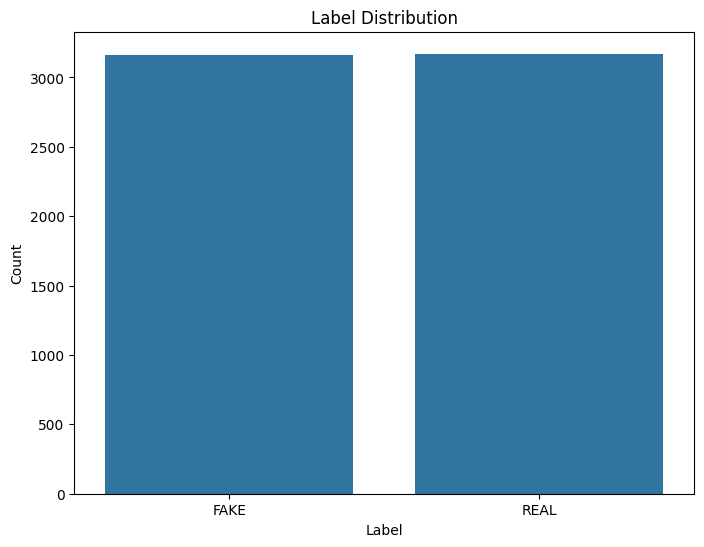

In [ ]:
# prompt: label count plot

import seaborn as sns

# Assuming 'label' is the column containing the labels
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


In [ ]:
stop_words = stopwords.words("english")
stemmer = SnowballStemmer("english")
text_cleaning_re = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"

In [ ]:
def preprocess(text, stem=False):
    # Remove link,user and special characters
    text = re.sub(text_cleaning_re, ' ', str(text).lower()).strip()
    tokens = []
    for token in text.split():
        if token not in stop_words:
            if stem:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

In [ ]:
df.text = df.text.apply(lambda x: preprocess(x))

In [ ]:
df

,text,label
0,smell hillary fear daniel greenfield shillman ...,FAKE
1,watch exact moment paul ryan committed politic...,FAKE
2,kerry go paris gesture sympathy u secretary st...,REAL
3,bernie supporters twitter erupt anger dnc trie...,FAKE
4,battle new york primary matters primary day ne...,REAL
...,...,...
6330,state department says find emails clinton spec...,REAL
6331,p pbs stand plutocratic pentagon p pbs stand p...,FAKE
6332,anti trump protesters tools oligarchy informat...,FAKE
6333,ethiopia obama seeks progress peace security e...,REAL


In [ ]:
TRAIN_SIZE = 0.8
# MAX_NB_WORDS = 100000
MAX_SEQUENCE_LENGTH = 30

In [ ]:
train_data, test_data = train_test_split(df, test_size=1-TRAIN_SIZE,
                                         random_state=7) # Splits Dataset into Training and Testing set
print("Train Data size:", len(train_data))
print("Test Data size", len(test_data))

Train Data size: 5068
Test Data size 1267


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_data.text)

word_index = tokenizer.word_index
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size :", vocab_size)

Vocabulary Size : 61026


In [ ]:


from keras.preprocessing.sequence import pad_sequences

x_train = pad_sequences(tokenizer.texts_to_sequences(train_data.text),
                        maxlen = MAX_SEQUENCE_LENGTH)
x_test = pad_sequences(tokenizer.texts_to_sequences(test_data.text),
                       maxlen = MAX_SEQUENCE_LENGTH)

print("Training X Shape:",x_train.shape)
print("Testing X Shape:",x_test.shape)



Training X Shape: (5068, 30)
Testing X Shape: (1267, 30)


In [ ]:
labels = train_data.label.unique().tolist()
labels

['FAKE', 'REAL']

In [ ]:
encoder = LabelEncoder()
encoder.fit(train_data.label.to_list())

y_train = encoder.transform(train_data.label.to_list())
y_test = encoder.transform(test_data.label.to_list())

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (5068, 1)
y_test shape: (1267, 1)


In [ ]:

!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2025-04-14 07:11:18--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-04-14 07:11:18--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-04-14 07:11:19--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
GLOVE_EMB = './glove.6B.300d.txt'
EMBEDDING_DIM = 300
LR = 1e-3
BATCH_SIZE = 128
EPOCHS = 10
MODEL_PATH = '.../output/kaggle/working/best_model.hdf5'

In [ ]:
embeddings_index = {}

f = open(GLOVE_EMB)
for line in f:
  values = line.split()
  word = value = values[0]
  coefs = np.asarray(values[1:], dtype='float32')
  embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' %len(embeddings_index))

Found 400000 word vectors.


In [ ]:
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in word_index.items():
  embedding_vector = embeddings_index.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector

In [ ]:

embedding_layer = tf.keras.layers.Embedding(vocab_size,
                                          EMBEDDING_DIM,
                                          weights=[embedding_matrix],
                                          input_length=MAX_SEQUENCE_LENGTH,
                                          trainable=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:

from tensorflow.keras.layers import Conv1D, Bidirectional, LSTM, Dense, Input, Dropout
from tensorflow.keras.layers import SpatialDropout1D
from tensorflow.keras.callbacks import ModelCheckpoint


In [ ]:
sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32')
embedding_sequences = embedding_layer(sequence_input)
x = SpatialDropout1D(0.2)(embedding_sequences)
x = Conv1D(64, 5, activation='relu')(x)
x = Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2))(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(sequence_input, outputs)

In [ ]:


from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

model.compile(optimizer=Adam(learning_rate=LR), loss='binary_crossentropy',
              metrics=['accuracy'])
ReduceLROnPlateau = ReduceLROnPlateau(factor=0.1,
                                     min_lr = 0.01,
                                     monitor = 'val_loss',
                                     verbose = 1)



In [ ]:

history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
                    validation_data=(x_test, y_test), callbacks=[ReduceLROnPlateau])

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - accuracy: 0.6022 - loss: 0.6358 - val_accuracy: 0.7932 - val_loss: 0.4510 - learning_rate: 0.0010
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - accuracy: 0.7981 - loss: 0.4413 - val_accuracy: 0.8327 - val_loss: 0.3887 - learning_rate: 0.0010
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.8410 - loss: 0.3607 - val_accuracy: 0.8382 - val_loss: 0.3696 - learning_rate: 0.0010
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.8699 - loss: 0.2990 - val_accuracy: 0.8366 - val_loss: 0.3683 - learning_rate: 0.0010
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.9128 - loss: 0.2217 - val_accuracy: 0.8382 - val_loss: 0.3836 - learning_rate: 0.0010
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - accuracy: 0.9386 - loss: 0.1701 - val_accuracy: 0.8311 - val_loss: 0.4343 - learning_rate: 0.0010
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.9423 - loss: 0.1406 

In [ ]:
def decode_sentiment(score):
    return "Real" if score>0.5 else "Fake"


scores = model.predict(x_test, verbose=1, batch_size=10000)
y_pred_1d = [decode_sentiment(score) for score in scores]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


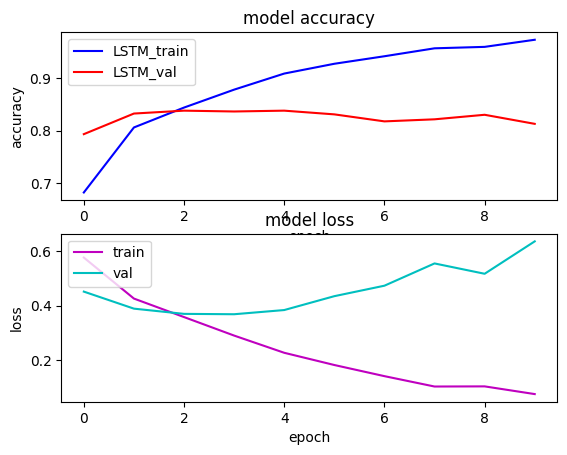

In [ ]:


s, (at, al) = plt.subplots(2,1)
at.plot(history.history['accuracy'], c= 'b')
at.plot(history.history['val_accuracy'], c='r')
at.set_title('model accuracy')
at.set_ylabel('accuracy')
at.set_xlabel('epoch')
at.legend(['LSTM_train', 'LSTM_val'], loc='upper left')

al.plot(history.history['loss'], c='m')
al.plot(history.history['val_loss'], c='c')
al.set_title('model loss')
al.set_ylabel('loss')
al.set_xlabel('epoch')
al.legend(['train', 'val'], loc = 'upper left')



In [ ]:
# prompt: use LabelEncoder for a list

# Assuming you have a list called 'my_list' that you want to encode

encoder = LabelEncoder()
test_data_list = encoder.fit_transform(test_data.label.to_list())
pred_list = encoder.fit_transform(y_pred_1d)


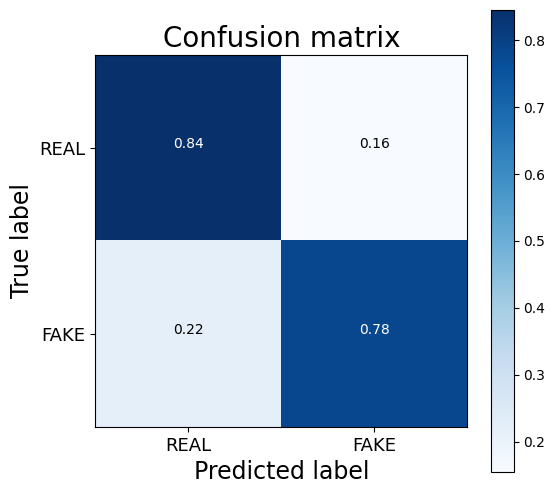

In [ ]:
cnf_matrix = confusion_matrix(test_data_list, pred_list)
plt.figure(figsize=(6,6))
plot_confusion_matrix(cnf_matrix, classes=test_data.label.unique(), title="Confusion matrix")
plt.show()

In [73]:
# prompt: new data predict with model

def predict_new_data(model, new_text):
    """Predicts the label for new text data using the trained model.

                       Args:
        model: The trained Keras model.
        new_text: A string representing the new text to predict.

    Returns:
        A string: 'Real' or 'Fake' representing the predicted label.
    """

    # Preprocess the new text
    new_text = preprocess(new_text)

    # Tokenize and pad the new text
    new_text_seq = tokenizer.texts_to_sequences([new_text])
    new_text_padded = pad_sequences(new_text_seq, maxlen=MAX_SEQUENCE_LENGTH)

    # Make prediction
    prediction = model.predict(new_text_padded)

    # Decode sentiment
    predicted_label = decode_sentiment(prediction[0][0])

    return predicted_label

# Example usage:
new_text = """"Scientists Discover That Cats Have Been Secretly Running the World's Economy for Decades"

In a shocking revelation, a team of researchers from the International Institute of Pet Studies (IIPS) have uncovered evidence suggesting that cats, not human economists, have been secretly controlling global financial markets since the 1990s. According to the study, cats use a combination of subtle body language and purring vibrations to influence stock market trends, banking policies, and even global trade agreements. Experts are baffled, and stock markets are reportedly on edge, as one thing is clear—catnip is now the most valuable commodity in the world."""  # Replace with your new text
predicted_label = predict_new_data(model, new_text)
print(f"Predicted Label for the new text: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Label for the new text: Fake


In [85]:
txt="""Battle for 2024 Primary Day: New York Shaping the Presidential Race

As Primary Day arrives in New York, all eyes are on the Empire State, where both Democratic and Republican front-runners are fighting to solidify their positions ahead of the party conventions. Hillary Clinton and Donald Trump are leading their respective parties in the polls, but the path to clinching the nomination remains anything but certain.

Trump, despite suffering losses in some recent contests, is still riding high in the polls and remains confident about his chances. The former president has vowed to secure enough delegates in New York to prevent a contested Republican convention. With 95 delegates at stake, Trump needs to capture at least 50 percent of the vote statewide to solidify his path forward. Meanwhile, his closest challenger, Senator Ted Cruz of Texas, is trailing behind in the polls but still hopes for a big win in New York to gain momentum. Cruz, who has promised to “beat Hillary” in key battleground states in November, is still in the race, though his chances are shrinking as Trump’s lead grows.

On the Democratic side, former Secretary of State Hillary Clinton is in a tight race with Vermont Senator Bernie Sanders. Clinton, though favored to win the state, faces pressure after suffering unexpected losses in some of the earlier primaries. Sanders, who has been gaining momentum among younger voters and independents, has told his supporters that a strong showing in New York could help him close the gap with Clinton. However, if Sanders loses by more than 10 points, he will need to win around 80 percent of the remaining delegates to stay in the race.

Ohio Governor John Kasich, while trailing in the Republican race, is also hoping for a significant result in New York. A strong performance could potentially make him a player in the wider nomination fight. For both Clinton and Trump, winning New York could be a game-changer. Trump needs to win big to continue his march toward the nomination, while Clinton is hoping for a decisive victory to quell any talk of a Sanders upset.

With the stakes so high, New York Primary Day promises to be a pivotal moment in the 2024 race for the White House. While Trump and Clinton are the favorites, anything can happen on the road to the conventions. All eyes will be on the results as they come in on Primary Day.
"""
predicted_label = predict_new_data(model, txt)
print(f"Predicted Label for the new text: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Label for the new text: Real
